In [1]:
import matplotlib.pyplot as plt
plt.style.use(f'plots.mplstyle')
%config InlineBackend.figure_format = 'retina'

import numpy as np
from krono import const
from scipy.integrate import trapezoid
from importlib import reload

import wind_profiles; reload(wind_profiles)
import geoid; reload(geoid)

# constants for Neptune; Jacobson 2009
r_ref = 25225e5
jn = 3408.43e-6, -33.4e-6, 0. # for reference, j2 and j4 uncertainties are 4.5e-6 and 2.9e-6
gm = 6836527e15

periods = 15.11, 16.11, 17.11

from occultation_data import neptune as occultation_radii

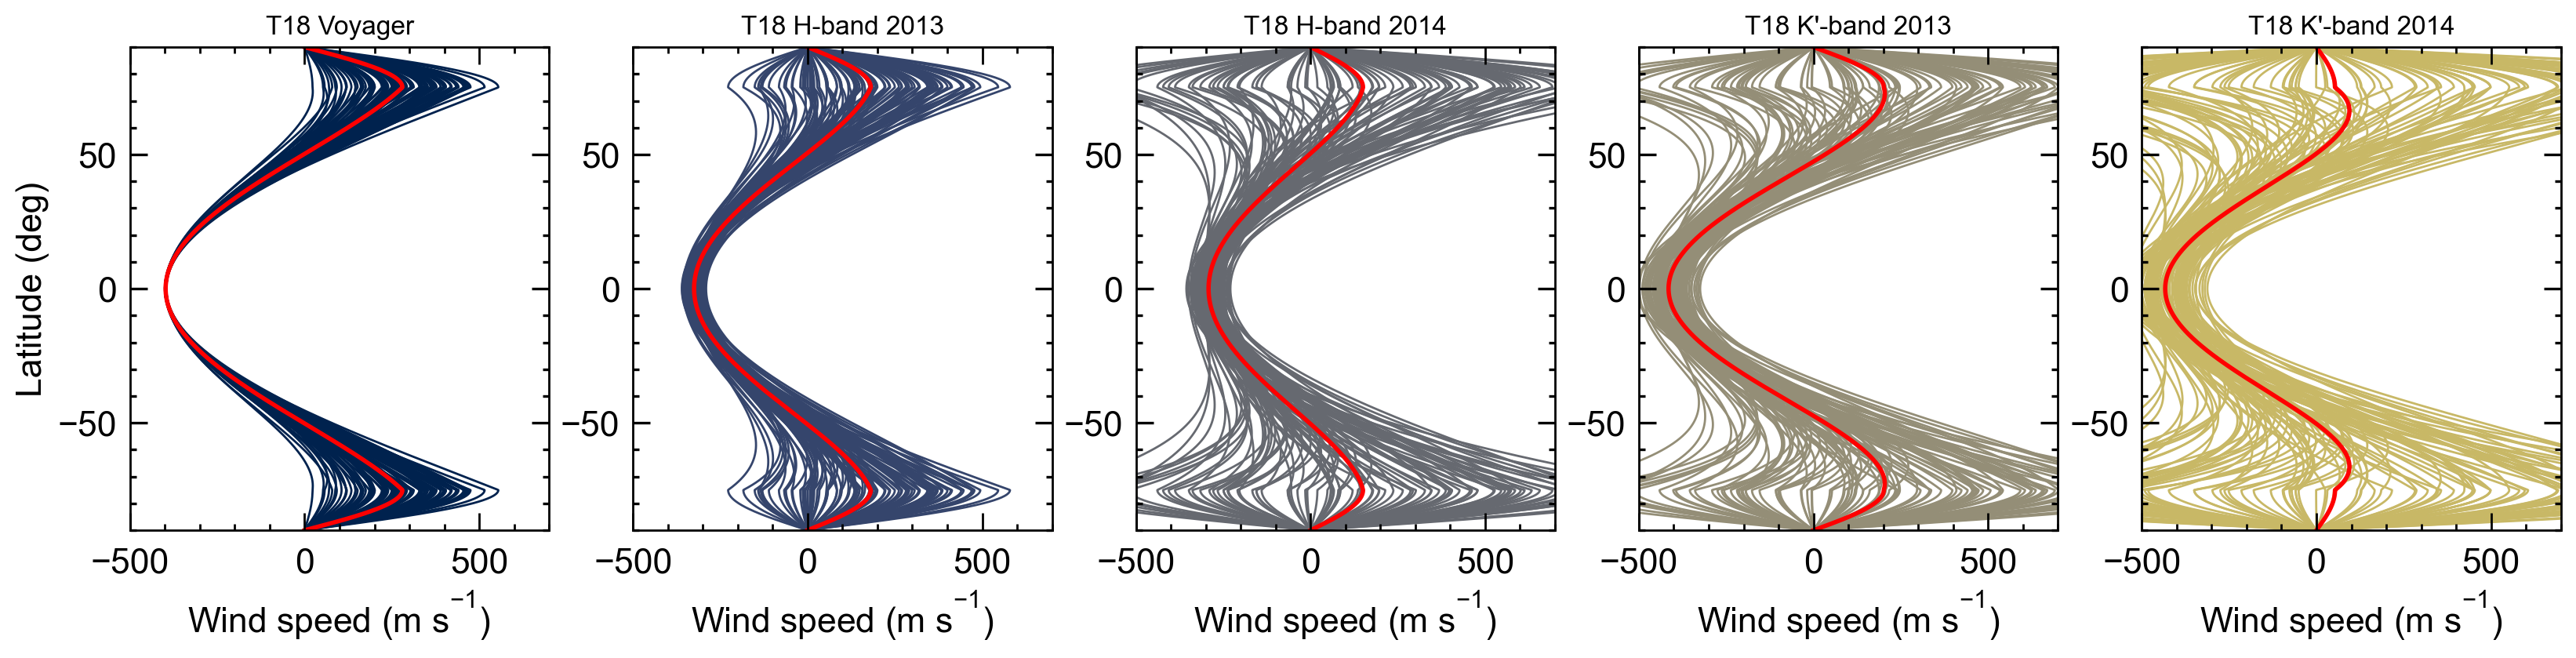

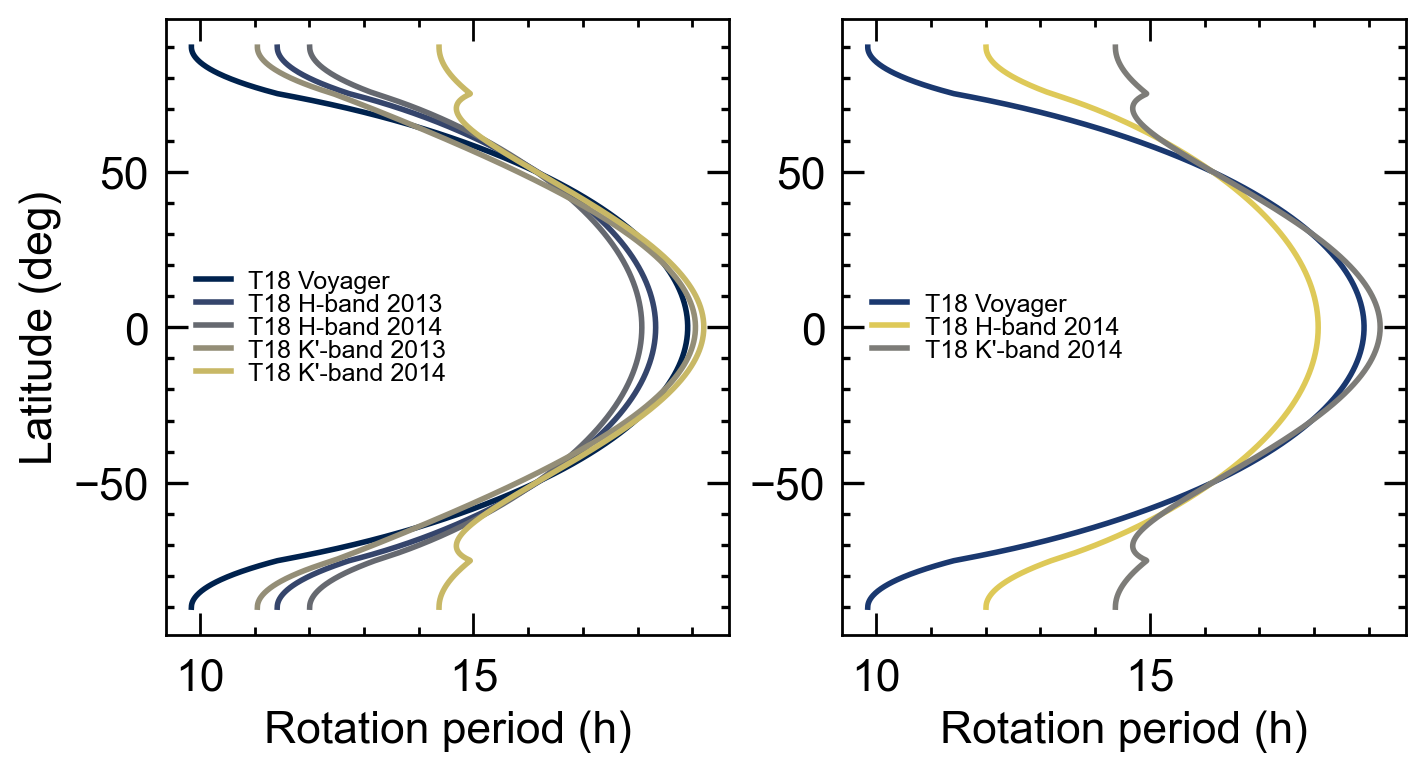

In [7]:
# plot Neptune wind profiles to get oriented
wind_labels_all = {
    'voyager':'T18 Voyager',
    'h-band 2013':'T18 H-band 2013',
    'h-band 2014':'T18 H-band 2014',
    'k-band 2013':"T18 K'-band 2013",
    'k-band 2014':"T18 K'-band 2014",
}
wind_options = {
    'voyager':{
        'label':'T18 Voyager',
        'linestyle':'-',
        'linewidth':2.5,
        'color':plt.get_cmap('cividis')(1. / 8),
    },
    # 'h-band 2013':{
    #     'label':"T18 H-band 2013",
    #     'linestyle':'-.',
    #     'linewidth':1,
    #     'color':plt.get_cmap('cividis')(7. / 8),
    # },
    'h-band 2014':{
        'label':'T18 H-band 2014',
        'linestyle':'--',
        'linewidth':1,
        'color':plt.get_cmap('cividis')(7. / 8),
    },
    'k-band 2014':{
        'label':"T18 K'-band 2014",
        'linestyle':'-.',
        'linewidth':1,
        'color':plt.get_cmap('cividis')(4. / 8),
    },
}

ph = wind_profiles._phi_grid
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
for iwind, (wind_option, wind_label) in enumerate(wind_labels_all.items()):
    color = plt.get_cmap('cividis')(1. * iwind / len(list(wind_labels_all)))

    ax[iwind].plot(wind_profiles.neptune_wind_profile_tollefson2018(ph, option=wind_option, pole_attenuation='cosine', randomize=False) * 1e-2, ph * 180 / np.pi, 'r-', zorder=1)
    np.random.seed(2025)
    for i in range(100):
        ax[iwind].plot(wind_profiles.neptune_wind_profile_tollefson2018(ph, option=wind_option, pole_attenuation='cosine', randomize=True) * 1e-2, ph * 180 / np.pi, color=color, lw=1, zorder=-1)
    ax[iwind].set_title(wind_label, fontsize=12)

[z.set_xlim(-500, 700) for z in ax]
[z.set_ylim(-90, 90) for z in ax]
[z.set_xlabel(r'Wind speed (m s$^{-1}$)') for z in ax]
ax[0].set_ylabel('Latitude (deg)')

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for iwind, (wind_option, wind_label) in enumerate(wind_labels_all.items()): # all five Tollefson+2018 profiles and old color scheme
    color = plt.get_cmap('cividis')(1. * iwind / len(list(wind_labels_all)))
    omega = wind_profiles.neptune_omega_tot_interpolant(option=wind_option, pole_attenuation='cosine', randomize=False)
    ax[0].plot(np.pi * 2. / (omega(ph) * 3600), ph * 180 / np.pi, color=color, label=wind_label)

for iwind, (wind_option, spec) in enumerate(wind_options.items()): # pare down to three Tollefson+2018 profiles with more discernable colors
    omega = wind_profiles.neptune_omega_tot_interpolant(option=wind_option, pole_attenuation='cosine', randomize=False)
    ax[1].plot(np.pi * 2. / (omega(ph) * 3600), ph * 180 / np.pi, color=spec['color'], label=spec['label'])

ax[0].set_xlabel('Rotation period (h)')
ax[1].set_xlabel('Rotation period (h)')
ax[0].set_ylabel('Latitude (deg)')
ax[0].legend(fontsize=9)
ax[1].legend(fontsize=9)


    period      r_pol r_eq_geoid       r_eq     h_mean
     15.11    24285.8    24779.7    24761.9      16.44
     16.11    24285.8    24734.6    24761.9      38.50
     17.11    24285.8    24697.6    24761.9      56.66


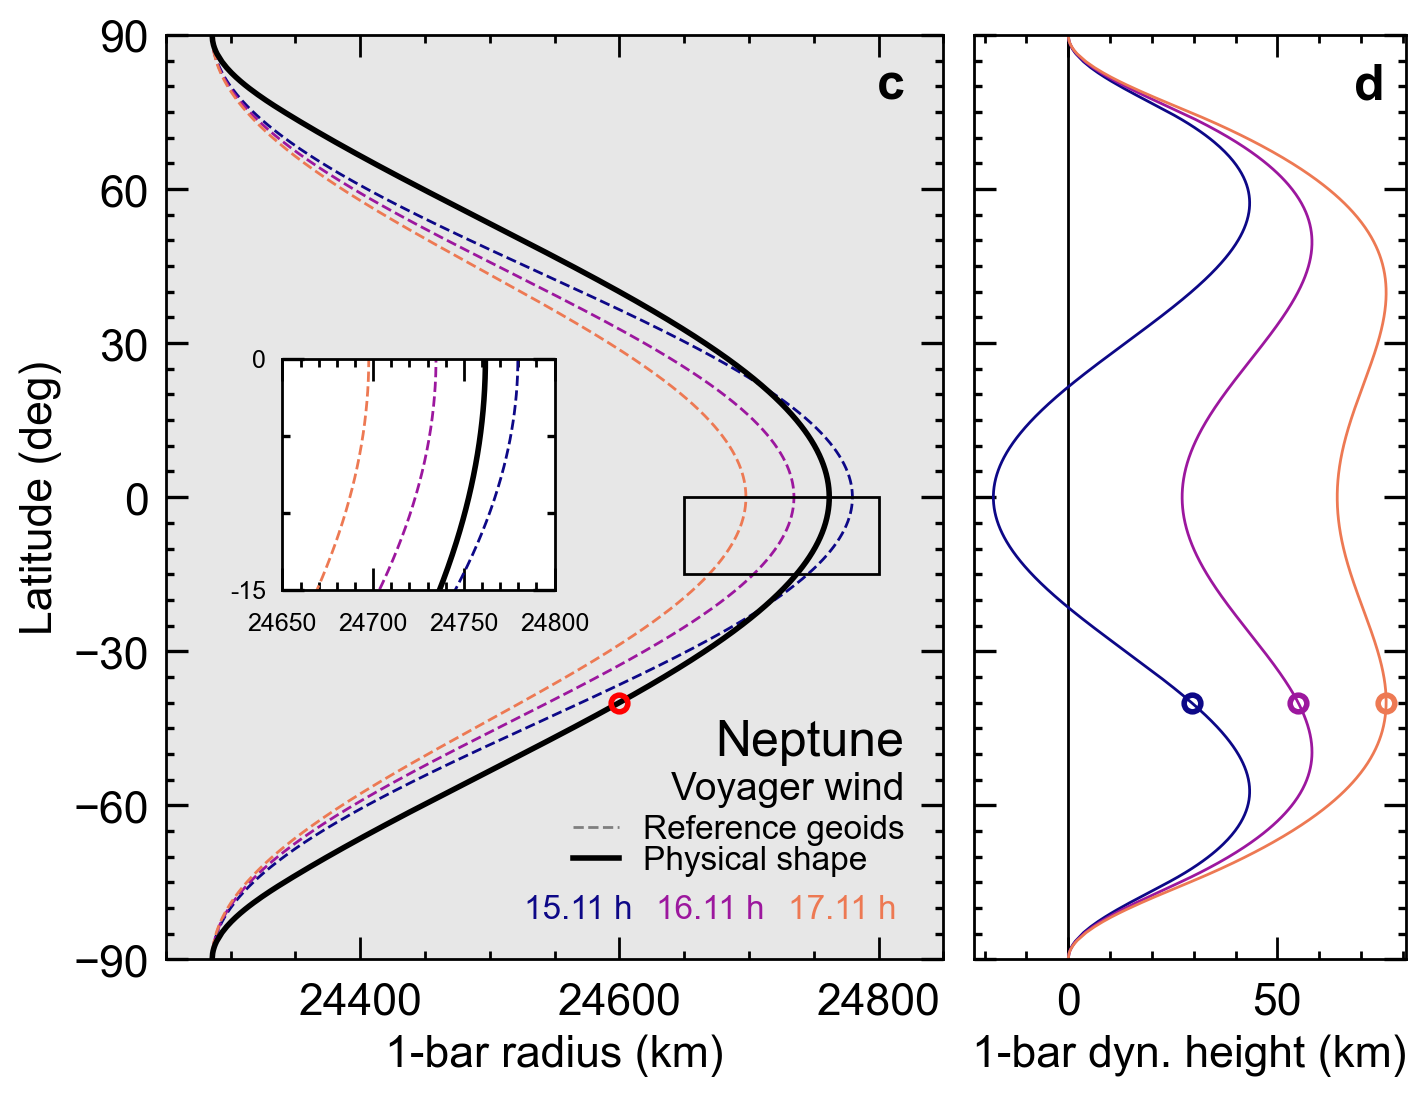

In [8]:
# main shape model plot for paper
def shape_plot(xlim=(24250, 24850), skip_inset_eq=False, inset_xlim=(24650, 24800), inset_ylim=(-15, 0), inset_loc=[0.15, 0.4, 0.35, 0.25]):    
    from matplotlib.patches import Rectangle
    fig, ax = plt.subplots(1, 2, figsize=(8, 6), gridspec_kw={'width_ratios':(9, 5), 'wspace':0.05})
    if not skip_inset_eq: # inset near equator
        ax_inset_eq = ax[0].inset_axes(inset_loc, xlim=inset_xlim, ylim=inset_ylim, xticklabels=[], yticklabels=[])
        ax[0].add_artist(Rectangle((inset_xlim[0], inset_ylim[0]), inset_xlim[1]-inset_xlim[0], inset_ylim[1]-inset_ylim[0], facecolor='none', edgecolor='k', lw=1, zorder=5))
        num_minor_ticks = (inset_xlim[1] - inset_xlim[0]) // 50 + 1
        if num_minor_ticks <=3: num_minor_ticks += 2
        xticks = np.linspace(inset_xlim[0], inset_xlim[1], num_minor_ticks)
        # print(inset_xlim, xticks, num_minor_ticks)
        ax_inset_eq.set_xticks(xticks, minor=True)
        ax_inset_eq.set_xticks([inset_xlim[0], inset_xlim[1]], [inset_xlim[0], inset_xlim[1]], minor=False, fontsize=9)
        ax_inset_eq.set_yticks(inset_ylim[0] + 5 * np.array([0, 1, 2, 3]), minor=True)
        ax_inset_eq.set_yticks(inset_ylim, inset_ylim, minor=False, fontsize=9)
        ax_inset_eq.set_xlim(*inset_xlim)

    yl = -90, 90 # ax[1].get_ylim()
    ax[1].vlines(0, *yl, color='k', linewidth=1, zorder=-1)
    for z in ax:
        z.set_yticks(np.linspace(-90, 90, 7), minor=False)
        z.set_yticks(np.linspace(-90, 90, 37), minor=True)
        z.set_ylim(*yl)
    ax[1].tick_params(labelleft=False)
    ax[0].set_ylabel('Latitude (deg)')
    # ax[0].set_xlabel('100-mbar radius (km)')
    # ax[1].set_xlabel('100-mbar dyn. height (km)')
    ax[0].set_xlabel('1-bar radius (km)')
    ax[1].set_xlabel('1-bar dyn. height (km)')
    ax[0].set_facecolor('#e7e7e7')
    ax[0].set_xlim(*xlim)

    if skip_inset_eq:
        return ax
    else:
        return ax, ax_inset_eq

ax, ax_inset = shape_plot()
ax_inset.set_xticks(24650 + 10 * np.arange(15), minor=True)
ax_inset.set_xticks(24650 + 50 * np.arange(4), 24650 + 50 * np.arange(4), minor=False, fontsize=9)

# inset axis highlights region near the occultation point instead:
# ax, ax_inset = shape_plot(inset_xlim=(24500, 24650), inset_ylim=(-45, -30))
# ax_inset.set_xticks(24500 + 10 * np.arange(15), minor=True)
# ax_inset.set_xticks([24500, 24550, 24600, 24650], [24500, 24550, 24600, 24650], minor=False, fontsize=9)

reload(geoid)
print(f"{'period':>10} {'r_pol':>10} {'r_eq_geoid':>10} {'r_eq':>10} {'h_mean':>10}")

omega = wind_profiles.neptune_omega_tot_interpolant(option='voyager', pole_attenuation='cosine', randomize=False)

r_pol = 25000e5
for i in range(10):
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation

    # compare to data and adjust r_pol
    latitude, radius = occultation_radii['voyager 2 egress']
    error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
    if abs(error_km) < 0.001: break
    r_pol += 1e5 * error_km
else:
    raise RuntimeError('failed in iterations to fit occultations')

# ax, ax_inset_eq, ax_inset_pol = plot(g, color='k', suppress_legend=True, skip_inset_pol=False, width_ratios=(9, 5), xlim_inset_pol=(24970, 24980))
ax[0].plot(1e-5 * g.r, g.lat, 'k-')
ax_inset.plot(1e-5 * g.r, g.lat, 'k-')
for occ, (latitude, radius) in occultation_radii.items():
    ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=2)
    ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=2)

# reference geoids depend on rigid rotation; loop through them now
for ip, p_rot_h in enumerate(periods):
    
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]
    g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    r_eq_ref = g_ref.r[len(g.mu) // 2]
    
    color = plt.get_cmap('plasma')(1. * (ip) / 3)

    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1, zorder=0)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=2)

    ax[0].text(0.6 + 0.17 * ip, 0.07, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='right', va='top', transform=ax[0].transAxes)
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq_ref:10.1f} {1e-5*r_eq:10.1f} {1e-5 * h_mean:10.2f}')

    if True: # save reference geoid output to disk
        outfile = f'models/neptune_model_voyager_wind_reference_geoid_{p_rot_h:.2f}h.txt'
        header  = f"detailed model output for Neptunes's 1-bar reference geoid, assuming rigid rotation with period {p_rot_h:.2f} h.\n"
        header += "see neptune_model_voyager_wind.txt for the corresponding shape model including the effect of the latitudinally varying atmospheric rotation.\n"
        header += 'that model used the symmetric Voyager wind profile from Tollefson et al. (2018, Icarus 311) Table 1.\n'
        header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
        # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
        fmt = '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.3f', 
        names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
        for name in names:
            header += f"{name:>16} "
        data = np.array([g_ref.mu, g_ref.phi, g_ref.lat, g_ref.planetographic_latitude, g_ref.psi, np.pi*2/(p_rot_h*3600) * np.ones_like(g_ref.mu), 1e-5 * g_ref.r]).T
        np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoids')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape') 
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.057), fontsize=12)
ax[0].text(0.95, 0.21, 'Neptune', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.165, 'Voyager wind', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)

for iax, c in enumerate('cd'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

if True: # save model output to disk
    outfile = 'models/neptune_model_voyager_wind.txt'
    header  = "detailed model output for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'this model assumes the symmetric Voyager wind profile from Tollefson et al. (2018, Icarus 311) Table 1.\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.3f', 
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

plt.savefig('figures/neptune_optimize_rpol.pdf')

    # period      r_pol r_eq_geoid       r_eq     h_mean
    #  15.11    24285.8    24779.7    24761.9      16.44
    #  16.11    24285.8    24734.6    24761.9      38.50
    #  17.11    24285.8    24697.6    24761.9      56.66


                          wind     period      r_pol       r_eq     h_mean
                       voyager      16.11    24285.8    24761.9      38.50
                   h-band 2014      16.11    24311.8    24769.5      18.18
                   k-band 2014      16.11    24325.7    24761.2       4.05


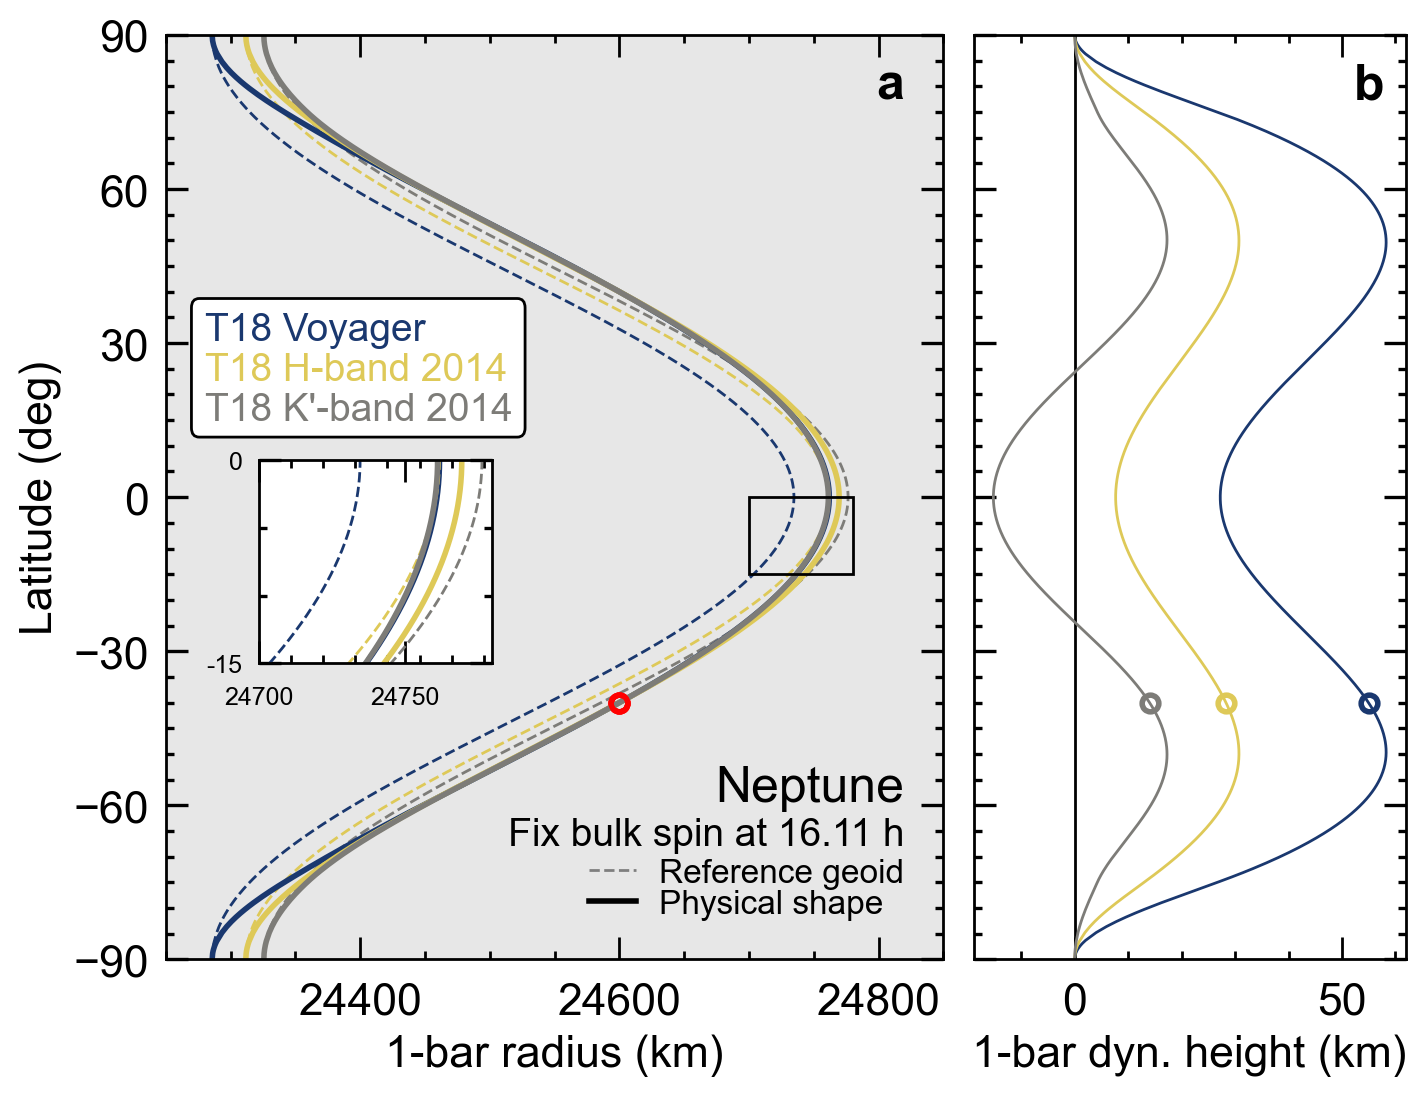

In [9]:
# same but fix background rotation and vary assumed wind profile

ax, ax_inset = shape_plot(inset_xlim=(24700, 24780), inset_loc=[0.12, 0.32, 0.3, 0.22])
ax_inset.set_xticks(24700 + 11 * np.arange(8), minor=True)
ax_inset.set_xticks([24700, 24750], [24700, 24750], minor=False, fontsize=9)

# inset axis highlights region near occultation instead?
# ax, ax_inset = shape_plot(inset_xlim=(24500, 24650), inset_ylim=(-45, -30), inset_loc=[0.12, 0.32, 0.3, 0.22])
# ax_inset.set_xticks(24500 + 10 * np.arange(15), minor=True)
# ax_inset.set_xticks([24500, 24550, 24600, 24650], [24500, 24550, 24600, 24650], minor=False, fontsize=9)

reload(geoid)
print(f"{'wind':>30} {'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")

p_rot_h = 16.11
# for iwind, (wind_option, wind_label) in enumerate(wind_labels.items()):
for iwind, (wind_option, spec) in enumerate(wind_options.items()):
    
    omega = wind_profiles.neptune_omega_tot_interpolant(option=wind_option, pole_attenuation='cosine', randomize=False)
    # color = plt.get_cmap('cividis')(1. * iwind / len(list(wind_labels)))
    color = spec['color']

    # fit isobaric shape to occultation
    r_pol = 25000e5
    for i in range(10):
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation

        # compare to data and adjust r_pol
        latitude, radius = occultation_radii['voyager 2 egress']
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')

    if True: # save model output to disk
        outfile = f"models/neptune_model_{wind_option.replace(' ', '_')}_wind.txt"
        header  = "detailed model output for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
        header += f'this model assumes the symmetric {wind_option.upper()} wind profile from Tollefson et al. (2018, Icarus 311) Table 1.\n'
        header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
        # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
        fmt = '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.3f', 
        names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
        for name in names:
            header += f"{name:>16} "
        data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
        np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

    # ax, ax_inset_eq, ax_inset_pol = plot(g, color='k', suppress_legend=True, skip_inset_pol=False, width_ratios=(9, 5), xlim_inset_pol=(24970, 24980))
    ax[0].plot(1e-5 * g.r, g.lat, color=color)
    ax_inset.plot(1e-5 * g.r, g.lat, color=color)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=2)
        ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=2)

    # create a rigidly rotating reference geoid for comparison
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]
    g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    
    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1, zorder=0)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=2)

    # ax[0].text(0.53, 0.95 - 0.04 * iwind, wind_label, color=color, fontsize=12, ha='left', va='top', transform=ax[0].transAxes)
    ax[0].text(0.05, 0.7 - 0.043 * iwind, spec['label'], color=color, fontsize=14, ha='left', va='top', transform=ax[0].transAxes)
    print(f'{wind_option:>30} {p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * h_mean:10.2f}')

from matplotlib.patches import Rectangle, FancyBboxPatch
ax[0].add_artist(FancyBboxPatch((0.043, 0.575), 0.409, 0.13, facecolor='w', edgecolor='k', zorder=0, transform=ax[0].transAxes, boxstyle='Round, pad=0.01'))

ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoid')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape') 
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.01), fontsize=12)
ax[0].text(0.95, 0.16, 'Neptune', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.115, 'Fix bulk spin at 16.11 h', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)

for iax, c in enumerate('ab'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

plt.savefig('figures/neptune_optimize_rpol_vary_wind.pdf')

                #           wind     period      r_pol       r_eq     h_mean
                #        voyager      16.11    24285.8    24761.9      38.50
                #    h-band 2014      16.11    24311.8    24769.5      18.18
                #    k-band 2014      16.11    24325.7    24761.2       4.05


In [10]:
# what planetary rotation period minimizes neptune's dynamical heights?

reload(geoid)
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")

omega = wind_profiles.neptune_omega_tot_interpolant(option='voyager', pole_attenuation='cosine', randomize=False) # the answer will depend on which wind option, though

r_pol = 25000e5
for i in range(10):
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation

    # compare to data and adjust r_pol
    latitude, radius = occultation_radii['voyager 2 egress']
    error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
    if abs(error_km) < 0.001: break
    r_pol += 1e5 * error_km
else:
    raise RuntimeError('failed in iterations to fit occultations')

r_eq = g.r[len(g.mu) // 2]

# iterate to find the period that minimizes the dynamical height
def zero_me(p_rot_h):
    g_ref = geoid.geoid(g.r[0], jn, r_ref, gm, omega=np.pi*2/(p_rot_h[0]*3600))
    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)
    print(f'{p_rot_h[0]:10.2f} {1e-5 * r_pol:10.2f} {1e-5 * r_eq:10.2f} {1e-5 * h_mean:10.2f}')
    return h_mean

from scipy.optimize import root
sol = root(zero_me, 16.11, tol=1e-10)
print(sol)
print(sol.x[0]) # 14.48 h


    period      r_pol       r_eq     h_mean
     16.11   24285.79   24761.86      38.50
     16.11   24285.79   24761.86      38.50
     16.11   24285.79   24761.86      38.50
     16.11   24285.79   24761.86      38.50
     14.18   24285.79   24761.86      -8.63
     14.53   24285.79   24761.86       1.49
     14.48   24285.79   24761.86       0.05
     14.48   24285.79   24761.86      -0.00
     14.48   24285.79   24761.86       0.00
     14.48   24285.79   24761.86      -0.00
     14.48   24285.79   24761.86       0.00
     14.48   24285.79   24761.86      -0.00
 message: The solution converged.
 success: True
  status: 1
     fun: -6.043248706393771e-08
       x: [ 1.448e+01]
  method: hybr
    nfev: 12
    fjac: [[-1.000e+00]]
       r: [-4.504e+06]
     qtf: [-3.032e-07]
14.47910899178623


In [11]:
# same exercise with split-style method -- same answer?

reload(geoid)
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")

omega = wind_profiles.neptune_omega_tot_interpolant(option='voyager', pole_attenuation='cosine', randomize=False)

def zero_me(p_rot_h):
    r_pol = 25000e5
    for i in range(10):
        g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=np.pi*2/(p_rot_h[0]*3600), omega=omega)

        # compare to data and adjust r_pol
        latitude, radius = occultation_radii['voyager 2 egress']
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')

    h_mean = -1. / 180 * trapezoid(g.h, x=g.lat)
    print(p_rot_h[0], h_mean)
    return 1e-5 * h_mean

from scipy.optimize import root
sol = root(zero_me, 16.11, tol=1e-10)
print(sol)
print(sol.x[0]) # 14.49 h


    period      r_pol       r_eq     h_mean
16.11 3831550.3131600353
16.11 3831550.3131600353
16.11 3831550.3131600353
16.110000240057705 3831550.7907090257
14.183929164722745 -884039.786178015
14.545012976825335 156246.04611869677
14.49077988414355 5363.018306036708
14.488852211607666 -33.808183353311485
14.488864287427903 0.007265231510003408
14.48886428483342 8.443991343180338e-09
14.488864284833417 4.221995671590169e-09
14.488864284833413 -1.3245476616753473e-08
14.488864284833417 4.221995671590169e-09
 message: The solution converged.
 success: True
  status: 1
     fun: 4.2219956715901694e-14
       x: [ 1.449e+01]
  method: hybr
    nfev: 13
    fjac: [[-1.000e+00]]
       r: [-5.793e+01]
     qtf: [-4.222e-14]
14.488864284833417


In [12]:
# again for the default method, looping through the different profiles provided by Tollefson

reload(geoid)
# print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")

def zero_me(p_rot_h, wind_option):
    omega = wind_profiles.neptune_omega_tot_interpolant(option=wind_option, pole_attenuation='cosine', randomize=False) # the answer will depend on which wind option, though

    r_pol = 25000e5
    for i in range(10):
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation

        # compare to data and adjust r_pol
        latitude, radius = occultation_radii['voyager 2 egress']
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')

    r_eq = g.r[len(g.mu) // 2]

    g_ref = geoid.geoid(g.r[0], jn, r_ref, gm, omega=np.pi*2/(p_rot_h[0]*3600))
    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)
    # print(f'{p_rot_h[0]:10.2f} {1e-5 * r_pol:10.2f} {1e-5 * r_eq:10.2f} {1e-5 * h_mean:10.2f}')
    return h_mean

# iterate to find the period that minimizes the dynamical height
from scipy.optimize import root
for wind_option, spec in wind_options.items():
    sol = root(zero_me, 16.11, tol=1e-10, args=(wind_option,))
    print(f'{wind_option:>12} {sol.x[0]:.2f}')

#      voyager 14.48
#  h-band 2014 15.28
#  k-band 2014 15.91


     voyager 14.48
 h-band 2014 15.28
 k-band 2014 15.91


In [13]:
# compare equatorial height with baseline method vs. split method. difference ~0.5 km

g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
print(1e-5 * g.r[len(g.mu) // 2])
g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=np.pi * 2 / 16.11 / 3600, omega=omega)
print(1e-5 * g.r[len(g.mu) // 2])

24761.859260668694
24761.595245945748
